# Comparison of Gene Expression PTRs with Chromatin PTRs

April 15, 2024

Goal: Determine if there is a pattern of difference between peak cycling chromatin and peak cycling gene expression.


Analyze the difference in timing between peak and trough gene expression with peak and trough promoter occupancy.

Eventually, we can explore other measures of the chromatin like nucleosome positioning.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [2]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()

In [3]:
# Refactored to use min max values rather than peak and trough values
# todo: indices of 225 do not have a phase and need to be fixed

ge_analysis.compute_ptr_maxmins_tps()

In [9]:
ge_analysis.ptrs_min_maxs.head(2)

,mother_ptr,daughter_ptr,ptr,min_value,min_f_idx,min_tp,min_phase,max_value,max_f_idx,max_tp,max_phase
orf_name,,,,,,,,,,,
YAL067W-A,1.000799,1.003462,1.001686,4.436323733130215,127,-14.6021,D_G1,4.462289453606121,49,-28.0,C_G1
YAL067C,1.270735,3.001155,1.692257,8.653574920824855e-05,142,-3.4408,D_G1,10.387151140225065,174,13.9203,D_S


In [5]:
selected_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
xin_dg1_genes = ['ASH1','EGT2','AMN1','DSE3','DSE4','PRY3','SCW11','DSE1','DSE2','CTS1']

Text(0.5, 1.0, 'Gene expression PTR per cell-cycle phase')

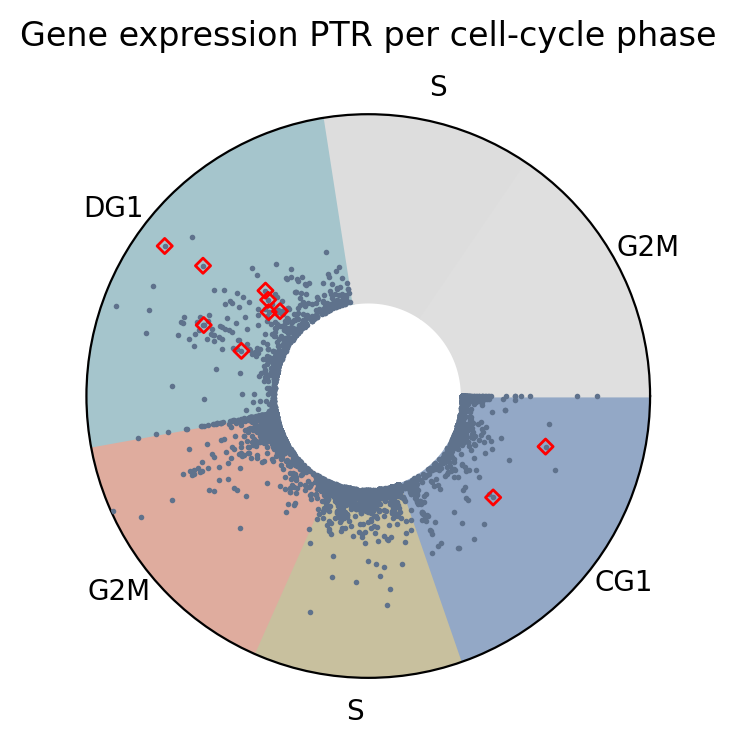

In [19]:
from src.PolarPlotter import PolarPlotter

polar_plotter = PolarPlotter()
ge_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(ge_analysis.ptrs_min_maxs, 
    selected_genes=xin_dg1_genes, ylim=(0.5, 2))
plt.title("Gene expression PTR per cell-cycle phase", pad=10)

In [10]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [11]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.114
1001/5574 - 00:00:06.145
2001/5574 - 00:00:11.795
3001/5574 - 00:00:17.347
4001/5574 - 00:00:22.766
5001/5574 - 00:00:28.169


In [12]:
promoter_analysis.correct_f_images_by_strand()

In [13]:
promoter_analysis.compute_small_fragments_promoter_occupancy()

In [14]:
promoter_analysis.compute_ptr_min_maxes()

Text(0.5, 1.0, 'Promoter occupancy PTR per cell-cycle phase')

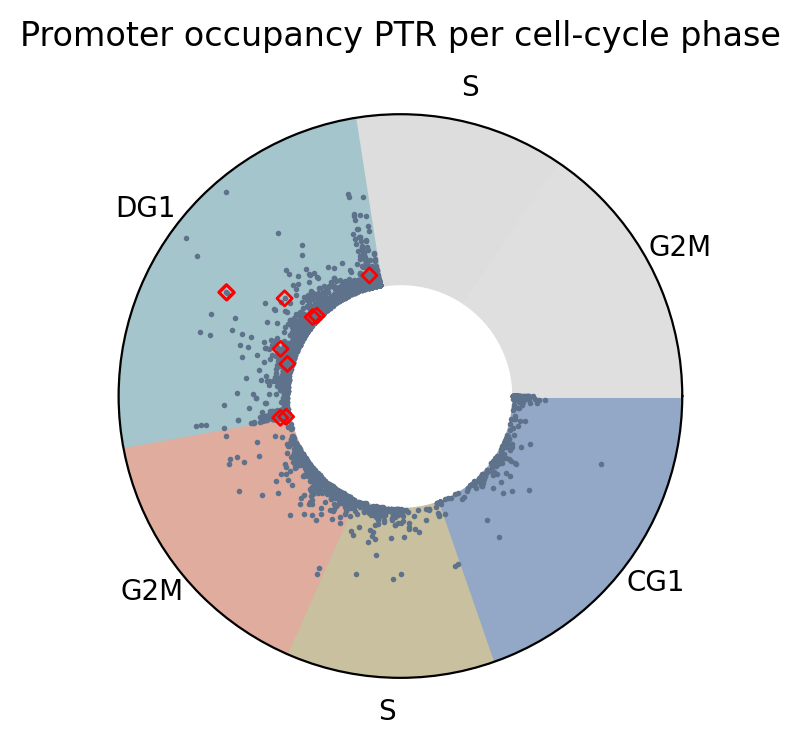

In [20]:
from src.PolarPlotter import PolarPlotter

polar_plotter = PolarPlotter()
prom_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(promoter_analysis.promoter_min_maxs, 
    selected_genes=xin_dg1_genes, ylim=(-5, 10))
plt.title("Promoter occupancy PTR per cell-cycle phase", pad=10)


In [126]:
"""
Objective: Compute a time delta between the max gene expression timepoint and the max
promoter occupancy timepoint.

Obstacle:
Mother and Daughter G1 are different lengths. What happens when I take a difference of the
two timepoints agnostic to what phase they are in. Are they comparable?

Edge cases:
1. A is near the start of G1, and B is near the end of G2M. Difference should be B-A_2
2. 

How do we handle DG1 being longer than CG1?
"""



'\nObjective: Compute a time delta between the max gene expression timepoint and the max\npromoter occupancy timepoint.\n\nObstacle:\nMother and Daughter G1 are different lengths. What happens when I take a difference of the\ntwo timepoints agnostic to what phase they are in. Are they comparable?\n\nEdge cases:\n1. A is near the start of G1, and B is near the end of G2M. Difference should be B-A_2\n2. \n\nHow do we handle DG1 being longer than CG1?\n'

In [269]:
# We'll do this as a scratch analysis for now, as we have yet to handle
# daughter-specific delta (10 minutes)         
def get_minimum_delta_term(data_df, lambda_val, A_key, B_key):
    """
    Compute the absolute minimum difference of the three cases:
    
    1. Difference of: B - A
    2. Difference if A was moved up a cell cycle (lambda)
    3. Difference if B was moved up a cell cycle (lambda)
    
    We want the absolute minimum, as we are interested in minimizing
    the delta.
    
    Returns:
    1. the absolute minimum vector
    2. the index of the column of the minimum for each row
    3. the minimum vector with the original sign returned
    """
        
    B = data_df[B_key].astype(float)
    A = data_df[A_key].astype(float)

    diff_B_A = B - A
    diff_B_2A = B - (A+lambda_val)
    diff_2B_A = (lambda_val+B) - A

    # Step 1: Calculate absolute values
    abs_B_A = np.abs(diff_B_A)
    abs_B_2A = np.abs(diff_B_2A)
    abs_2B_A = np.abs(diff_2B_A)
    
    # Step 2 and 3: Find minimum values and their indices
    combined_abs = np.stack((abs_B_A, abs_B_2A, abs_2B_A), axis=-1)
    min_values = np.min(combined_abs, axis=-1)
    min_indices = np.argmin(combined_abs, axis=-1)
    
    # Step 4: Determine signs
    signs = np.choose(min_indices, [np.sign(diff_B_A), 
        np.sign(diff_B_2A), np.sign(diff_2B_A)])
    
    return min_values, min_indices, signs*min_values

ge_prom_tp_diff = ge_analysis.ptrs_min_maxs[['ptr', 'max_tp']].join(
    prom_ptr_tp_rad_df[['ptr', 'max_tp']], 
    lsuffix='_ge', rsuffix='_prom')

# Note: daughter-specific delta has not been handled yet.
lambda_val = ge_analysis.config.intervals_wt1[0][1]
delta_val = ge_analysis.config.intervals_wt1[0][2]

_, min_case, signed_abs_min = get_minimum_delta_term(ge_prom_tp_diff, 
    lambda_val, 'max_tp_prom', 'max_tp_ge')

ge_prom_tp_diff['min_case'] = min_case
ge_prom_tp_diff['signed_abs_min'] = signed_abs_min

ge_prom_tp_diff

,ptr_ge,max_tp_ge,ptr_prom,max_tp_prom,min_case,signed_abs_min
orf_name,,,,,,
YAL067W-A,1.001686,-28.0,1.000040,-0.4645,0,-27.5355
YAL067C,1.692257,13.9203,2.219635,-36.1805,1,-18.0906
YAL064C-A,1.001086,-19.9201,1.000024,-0.2975,0,-19.6226
YAL064W,1.001539,2.3004,1.312250,-1.9527,0,4.2531
YAL063C-A,1.001743,37.6653,1.000012,-0.2975,1,-30.2286
...,...,...,...,...,...,...
YPR198W,1.003375,39.6862,1.130870,-17.5784,1,-10.9268
YPR199C,1.008389,12.9099,1.082768,-28.0000,1,-27.2815
YPR200C,1.047921,-28.0,3.581350,11.3943,2,28.7971


Text(0.5, 1.0, 'Distribution of thresholded time deltas\nfor gene expression and promoter occupancy\nthresholds: (1.3, 1.5), n=34')

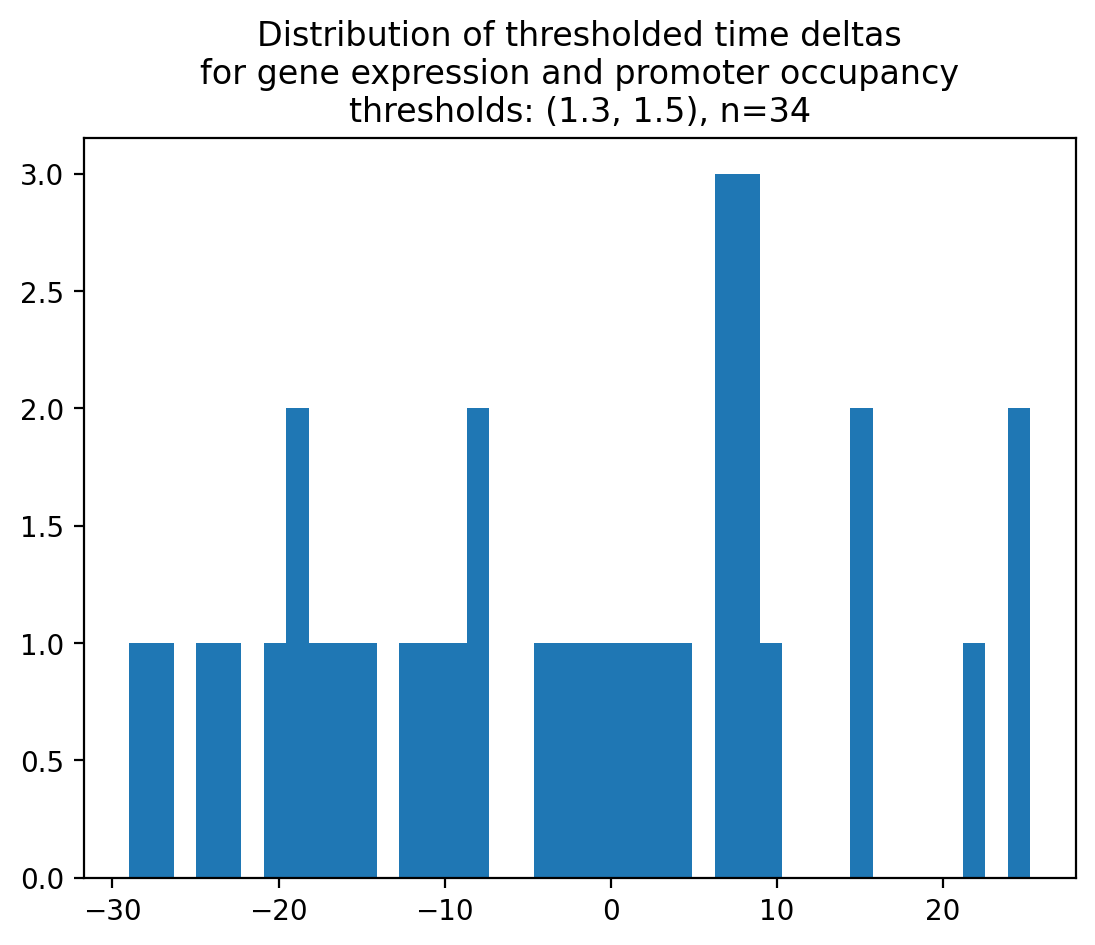

In [230]:
ge_t, prom_t = 1.3, 1.5

selected_ge_prom_diff_df = ge_prom_tp_diff[(ge_prom_tp_diff.ptr_ge > ge_t) & 
    (ge_prom_tp_diff.ptr_prom > prom_t)]

plt.hist(selected_ge_prom_diff_df.signed_abs_min, bins=40)
plt.title("Distribution of thresholded time deltas\n"
          f"for gene expression and promoter occupancy\nthresholds: {ge_t, prom_t}, "
          f"n={len(selected_ge_prom_diff_df)}")


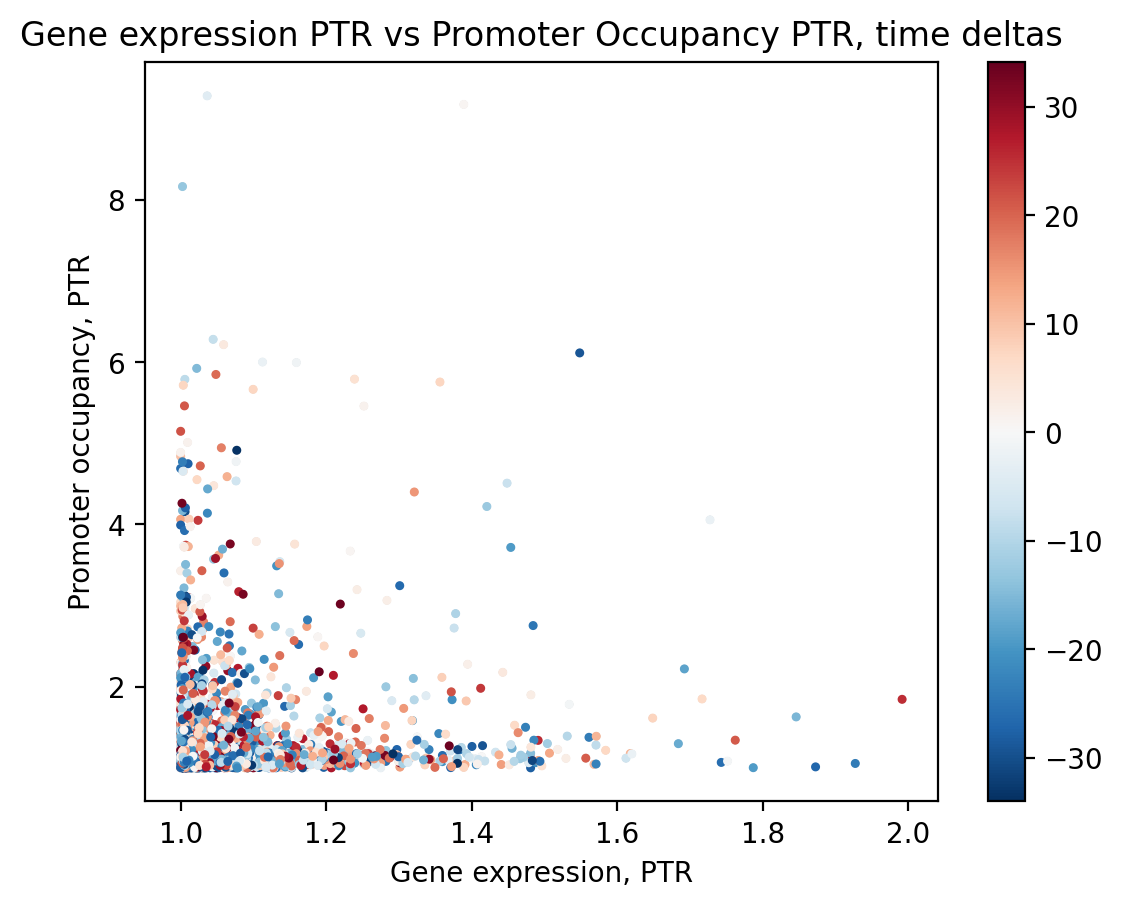

In [233]:
plt.scatter(ge_prom_tp_diff.ptr_ge, ge_prom_tp_diff.ptr_prom, s=8, 
    color='none', edgecolors='#aaa', lw=0.1)

plt.scatter(ge_prom_tp_diff.ptr_ge, ge_prom_tp_diff.ptr_prom, s=5, 
    c=ge_prom_tp_diff['signed_abs_min'], cmap='RdBu_r')
plt.title("Gene expression PTR vs Promoter Occupancy PTR, time deltas")
plt.xlabel("Gene expression, PTR")
plt.ylabel("Promoter occupancy, PTR")
plt.colorbar()

In [169]:
# Caveat to the above calculation:
# the above does not take into account the daughter-specific delta yet, so we may 
# need to think about what that means when adding or subtracting a lambda value
# as we may be identify the daughter vs mother peaks
#
# This is also subject to handling the identifiability issue with DG1 and CG1 genes
# currently, we may need to assume we will need to handle DG1 and CG1 exactly the same.

In [249]:
selected_ge_prom_diff_df = selected_ge_prom_diff_df.sort_values('signed_abs_min')

# Next: verify these time deltas by plotting the gene expression curves 
# along-side the promoter occupancy curves

# a heatmap would do this effectively
selected_ge_prom_diff_df.head()

,ptr_ge,max_tp_ge,ptr_prom,max_tp_prom,min_case,signed_abs_min
orf_name,,,,,,
YBR054W,1.548410,-30.9719,6.115157,-1.9527,0,-29.0192
YMR031C,1.301069,39.6862,3.245590,-1.9527,1,-26.5525
YJL079C,1.484380,-36.1805,2.753926,-11.6257,0,-24.5548
YOR066W,1.473961,-24.5372,1.500274,-1.2086,0,-23.3286
YGR230W,1.373020,-32.4601,1.840180,-11.6257,0,-20.8344


In [255]:
# And select by DG1 and CG1 curves
top_branch_indices = ge_analysis.config.get_Hpositions_for_branch('t')
bottom_branch_indices = ge_analysis.config.get_Hpositions_for_branch('b')
top_bottom_indices_concat = np.concatenate([top_branch_indices, bottom_branch_indices])

top_branch_tps = ge_analysis.config.get_timepoints_for_branch('t')
bottom_branch_tps = ge_analysis.config.get_timepoints_for_branch('b')
bottom_branch_tps += -bottom_branch_tps[0] + top_branch_tps[-1]
tps = np.concatenate([top_branch_tps, bottom_branch_tps])

ge_time_delta_df = ge_analysis.gene_expression_f.loc[
    selected_ge_prom_diff_df.index].astype(float)[top_bottom_indices_concat]
promoter_time_delta_df = promoter_analysis.sm_prom_occ_df.loc[
    selected_ge_prom_diff_df.index].astype(float)[top_bottom_indices_concat]


In [281]:
from src.sgd import get_gene_name_or_orf_name

Text(0.5, 0.98, 'Gene expression vs Promoter occupancy gene curves, high PTR genes')

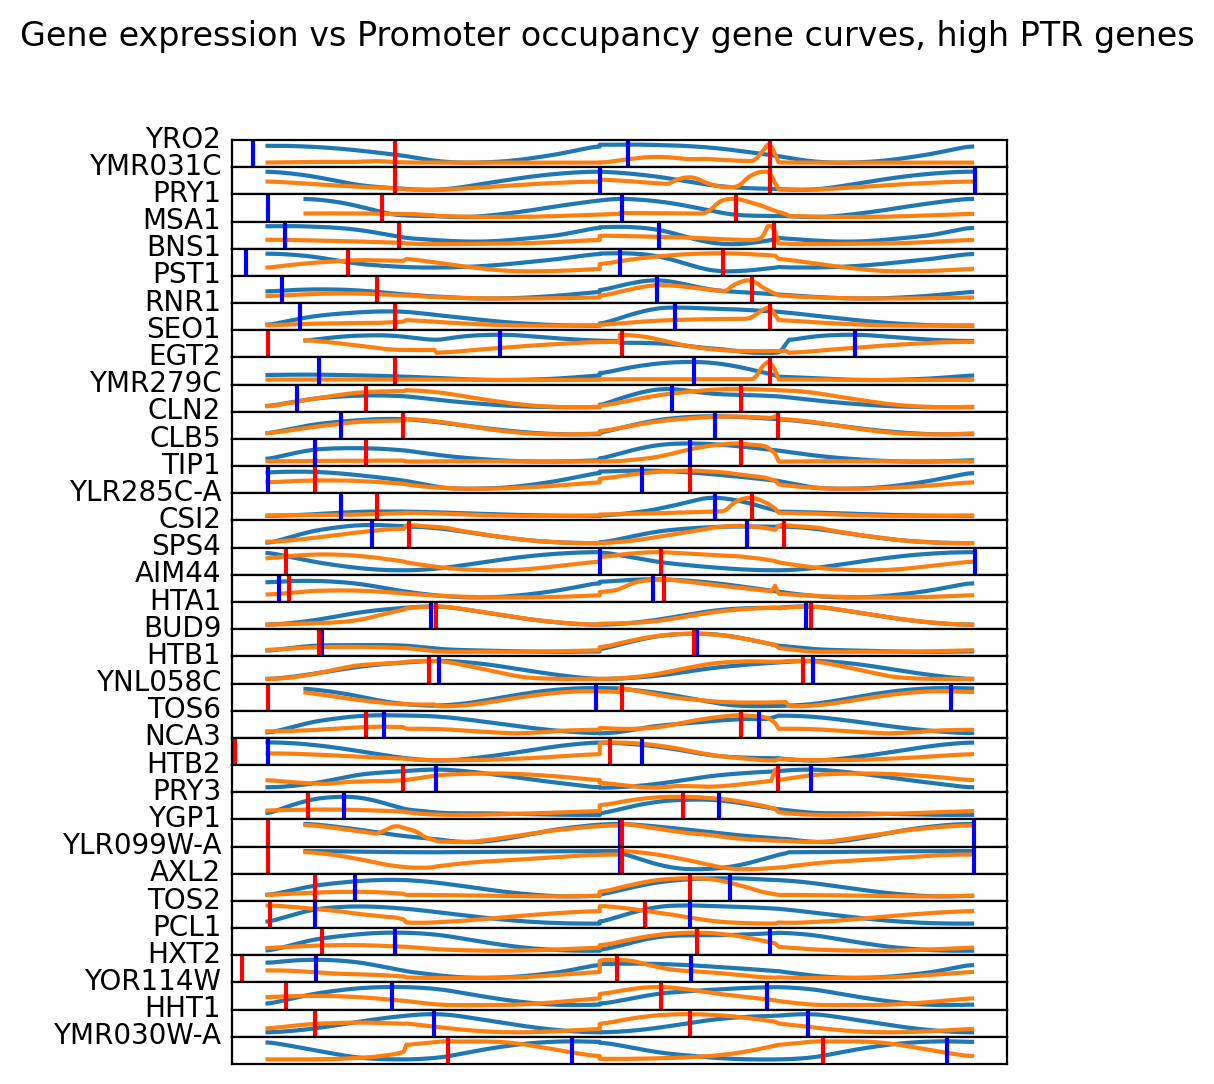

In [285]:
nrows = len(ge_time_delta_df)

fig, axs = plt.subplots(nrows, 1, figsize=(5, 6))
plt.subplots_adjust(hspace=0., wspace=0.25)

xs = tps

for i in range(nrows):
    ax = axs[i]
    gene_expression = ge_time_delta_df.iloc[i]
    promoter_occ = promoter_time_delta_df.iloc[i]
    
    def normalize_max_min(dat):
        min_v, max_v = dat.min(), dat.max()
        delta = max_v - min_v
        dat = dat.copy()
        dat = (dat - min_v) / delta
        return dat
        
    gene_expression = normalize_max_min(gene_expression)
    promoter_occ = normalize_max_min(promoter_occ)
    
    ax.plot(xs, gene_expression)
    ax.plot(xs, promoter_occ)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylim(-.25, 1.25)
    
    orf_name = selected_ge_prom_diff_df.iloc[i].name
    gene_name = get_gene_name_or_orf_name(orf_name, ge_analysis.geneset)
    
    max_ge_tp = float(selected_ge_prom_diff_df.max_tp_ge.iloc[i])
    max_prom_tp = float(selected_ge_prom_diff_df.max_tp_prom.iloc[i])
    
    ax.set_ylabel(gene_name, rotation=0, ha='right')
    ax.axvline(max_ge_tp, c='blue')
    ax.axvline(max_prom_tp, c='red')
    
    ax.axvline(max_ge_tp+lambda_val+delta_val, c='blue')
    ax.axvline(max_prom_tp+lambda_val+delta_val, c='red')

plt.suptitle("Gene expression vs Promoter occupancy gene curves, high PTR genes")


# TO DO: modify this analysis
#
#       handling the Daughter branch is tricky because S and G2M shows up twice
#       
#
